In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("datasets/cleaned_data.csv")

In [3]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'tenure_group', 'Additional_Service_Count', 'MCharges'],
      dtype='object')

In [4]:
x = df.drop(columns=['Churn'])
y = df['Churn']

In [5]:
x = x.drop(columns=["customerID", 'tenure_group', 'MCharges'])

In [6]:
print(x.shape)
print(y.shape)

(7043, 20)
(7043,)


In [7]:
x.dtypes

gender                       object
SeniorCitizen                 int64
Partner                      object
Dependents                   object
tenure                        int64
PhoneService                 object
MultipleLines                object
InternetService              object
OnlineSecurity               object
OnlineBackup                 object
DeviceProtection             object
TechSupport                  object
StreamingTV                  object
StreamingMovies              object
Contract                     object
PaperlessBilling             object
PaymentMethod                object
MonthlyCharges              float64
TotalCharges                float64
Additional_Service_Count      int64
dtype: object

In [8]:
x.select_dtypes(include='object').columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [9]:
for col in x.select_dtypes(include='object').columns:
    print(col, ":", x[col].unique())

gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No phone service' 'No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [10]:
binary_cols = []

for col in x.select_dtypes(include="object").columns:
    if x[col].nunique() == 2:
        binary_cols.append(col)

print(binary_cols)

multi_cols = []
for col in x.select_dtypes(include="object").columns:
    if x[col].nunique() > 2:
        multi_cols.append(col)

print(multi_cols)


['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [11]:
x[binary_cols] = x[binary_cols].replace({
    'Yes':1,
    'No':0,
    'Male':1,
    'Female':0,
})

x[binary_cols]

C:\Users\anmol\AppData\Local\Temp\ipykernel_4520\2281068270.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x[binary_cols] = x[binary_cols].replace({


,gender,Partner,Dependents,PhoneService,PaperlessBilling
0,0,1,0,0,1
1,1,0,0,1,0
2,1,0,0,1,1
3,1,0,0,0,0
4,0,0,0,1,1
...,...,...,...,...,...
7038,1,1,1,1,1
7039,0,1,1,1,1
7040,0,1,1,0,1
7041,1,1,0,1,1


In [12]:
x = pd.get_dummies(x,
    columns=multi_cols,
    drop_first=True,
    dtype=int)

In [13]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Additional_Service_Count               7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

In [14]:
x.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Additional_Service_Count,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,1,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,2,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,2,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,3,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,0,...,0,0,0,0,0,0,0,0,1,0


In [15]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y, 
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Additional_Service_Count"
]
scaler.fit(x_train[numerical_cols])

StandardScaler()

In [17]:

x_train[numerical_cols] = scaler.transform(x_train[numerical_cols])
x_test[numerical_cols] = scaler.transform(x_test[numerical_cols])

In [18]:
# x_train_scaled[:5]
# x_train_scaled = scaler.fit_transform(x_train)
# x_test_scaled = scaler.transform(x_test)

In [19]:
# import pandas as pd

# x_train_scaled = pd.DataFrame(
#     x_train_scaled,
#     columns=x_train.columns,
#     index=x_train.index
# )

# x_test_scaled = pd.DataFrame(
#     x_test_scaled,
#     columns=x_test.columns,
#     index=x_test.index
# )

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

In [22]:
model.fit(x_train, y_train)

LogisticRegression()

In [23]:
y_pred = model.predict(x_test)
print(y_pred[:20])

['No' 'Yes' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes'
 'No' 'No' 'No' 'Yes' 'No' 'No']


In [24]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy*100:.2f}")

Accuracy : 80.62


In [25]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nROC-AUC Score")
print(roc_auc_score(y_test, model.predict_proba(x_test)[:, 1]))





Confusion Matrix
[[927 108]
 [165 209]]

Classification Report
              precision    recall  f1-score   support

          No       0.85      0.90      0.87      1035
         Yes       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


ROC-AUC Score
0.8421969051125061


In [26]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier


In [37]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced"
)

In [38]:
rf_model.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, n_estimators=300, random_state=42)

In [39]:
rf_pred = rf_model.predict(x_test)

In [40]:
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Accuracy {rf_accuracy}")

Accuracy 0.7679205110007097


In [41]:
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))
print(accuracy_score(y_test, rf_pred))
print(roc_auc_score(y_test, rf_model.predict_proba(x_test)[:,1]))

[[793 242]
 [ 85 289]]
              precision    recall  f1-score   support

          No       0.90      0.77      0.83      1035
         Yes       0.54      0.77      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409

0.7679205110007097
0.845468754036529


In [42]:
# XG BOOST
! pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 5.8 MB/s eta 0:00:12
   - -------------------------------------- 2.9/69.5 MB 10.0 MB/s eta 0:00:07
   -- ------------------------------------- 3.7/69.5 MB 8.3 MB/s eta 0:00:08
   -- ------------------------------------- 4.5/69.5 MB 6.2 MB/s eta 0:00:11
   --- ------------------------------------ 5.2/69.5 MB 5.8 MB/s eta 0:00:12
   --- ------------------------------------ 5.8/69.5 MB 5.3 MB/s eta 0:00:12
   --- ------------------------------------ 6.8/69.5 MB 5.1 MB/s eta 0:00:13
   ---- ----------------------------------- 7.3/69.5 MB 4.8 MB/s eta 0:00:14
   ---- ----------------------------------- 8.4/69.5 MB 4.7 MB/s eta 0:00:14
   ----- ---------------------------------- 8.9/69.5 MB 4.6 MB/s eta 0:00:14
   ----- ---------------------------------- 9.2/69.5 MB 4.3 MB/s eta 0:00:14
   ----- ---------------------------------- 9.7/69.5 MB 4.0 MB/s eta 0:00:16
   --

In [ ]:
from xgboost import XGBClassifier

xg_model = XGBClassifier(
    random_state = 42,
    n_estimators = 300,
    learning_rate = 0.05,
    max_depth = 5,
    objective = "binary:logistic",
    eval_metric = "logloss"
)


In [46]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [47]:
print(y_train[:10])

[0 0 0 0 0 0 0 0 0 0]


In [48]:
xg_model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [49]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

xgb_pred = xg_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, xgb_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report")
print(classification_report(y_test, xgb_pred))

print("\nROC-AUC Score")
print(roc_auc_score(y_test, xg_model.predict_proba(x_test)[:, 1]))

Accuracy: 0.7934705464868701

Confusion Matrix
[[923 112]
 [179 195]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409


ROC-AUC Score
0.8380299155235218


In [55]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [56]:
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=2
)

In [57]:
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              max_depth=10, min_samples_leaf=5,
                                              n_estimators=300,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='recall', verbose=2)

In [58]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
0.8093645484949834


In [59]:
best_rf = RandomForestClassifier(
    max_depth=5,
    max_features='sqrt',
    min_samples_leaf=2,
    min_samples_split=2,
    n_estimators=200,
    random_state=42
)
best_rf.fit(x_train, y_train)

RandomForestClassifier(max_depth=5, min_samples_leaf=2, n_estimators=200,
                       random_state=42)

In [60]:
best_pred = best_rf.predict(x_test)

In [61]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, best_pred))
print(confusion_matrix(y_test, best_pred))
print(classification_report(y_test, best_pred))
print(roc_auc_score(y_test, best_rf.predict_proba(x_test)[:,1]))

Accuracy: 0.7877927608232789
[[959  76]
 [223 151]]
              precision    recall  f1-score   support

           0       0.81      0.93      0.87      1035
           1       0.67      0.40      0.50       374

    accuracy                           0.79      1409
   macro avg       0.74      0.67      0.68      1409
weighted avg       0.77      0.79      0.77      1409

0.8405009170993826


In [62]:
from sklearn.model_selection import RandomizedSearchCV

In [63]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7, 10],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5],
    "min_child_weight": [1, 3, 5]
}

In [65]:
random_search = RandomizedSearchCV(
    estimator=xg_model,
    param_distributions=param_dist,
    n_iter=30,
    scoring="recall",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)
random_search.fit(x_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           multi_strategy=None,
                                           n_estimators=300, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 10],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='recall', verbose=2)

In [66]:
print(random_search.best_params_)
print(random_search.best_score_)

{'subsample': 0.6, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}
0.5270903010033444


In [67]:
import joblib

joblib.dump(rf_model, "churn_model.pkl")

['churn_model.pkl']

In [68]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
4,tenure,0.171249
8,TotalCharges,0.129928
27,Contract_Two year,0.118740
7,MonthlyCharges,0.086598
12,InternetService_Fiber optic,0.079823
29,PaymentMethod_Electronic check,0.054787
26,Contract_One year,0.042578
15,OnlineSecurity_Yes,0.027834
21,TechSupport_Yes,0.025722
9,Additional_Service_Count,0.025620


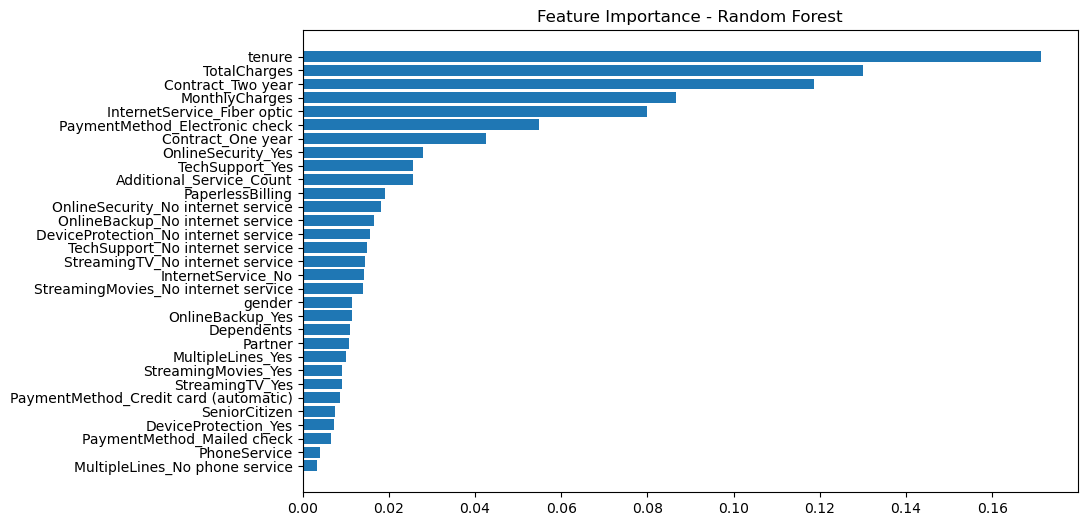

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.show()

In [70]:
#  IMPLEMENTING SHAP
! pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [71]:
import shap
explainer = shap.TreeExplainer(rf_model)

In [72]:
shap_values = explainer.shap_values(x_test)

In [74]:
print(type(shap_values))
print(len(shap_values))

<class 'numpy.ndarray'>
1409


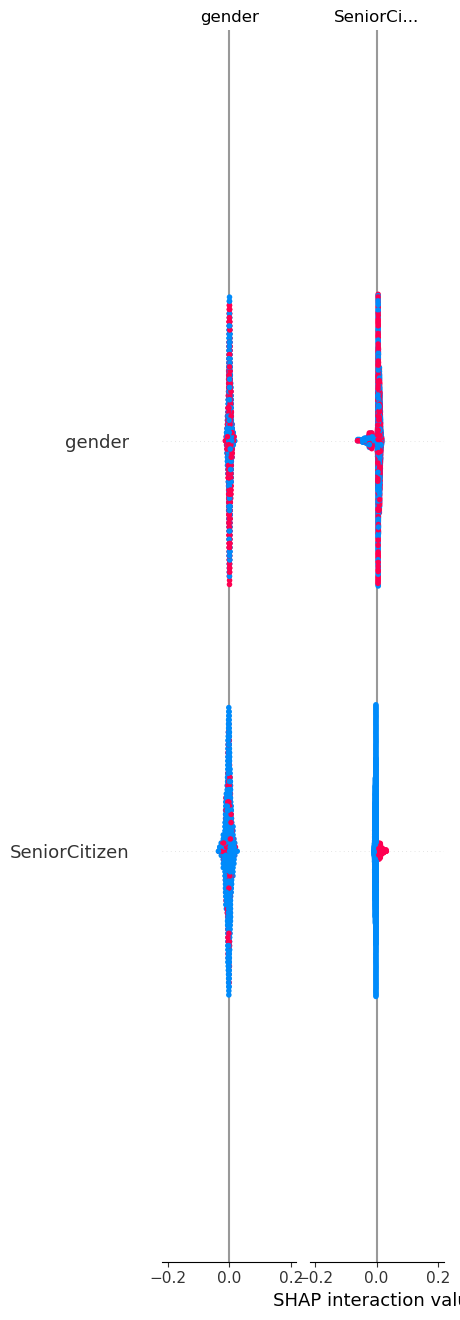

In [76]:
shap.summary_plot(shap_values, x_test, max_display=15)

In [77]:
shap.initjs()

In [84]:
print(type(shap_values))

<class 'numpy.ndarray'>


In [88]:
shap_vals = shap_values[:, :, 1]

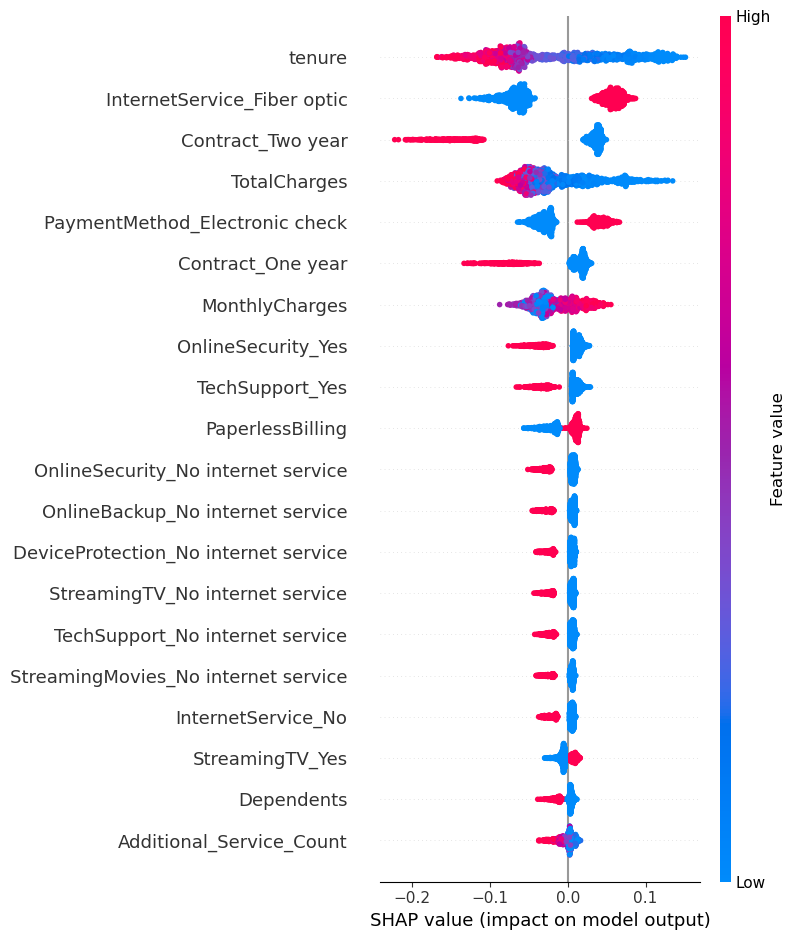

In [90]:
shap.summary_plot(shap_vals, x_test)

In [91]:
shap.plots.force(shap_vals[0])

TypeError: In v0.20, force plot now requires the base value as the first parameter! Try shap.plots.force(explainer.expected_value, shap_values) or for multi-output models try shap.plots.force(explainer.expected_value[0], shap_values[..., 0]).

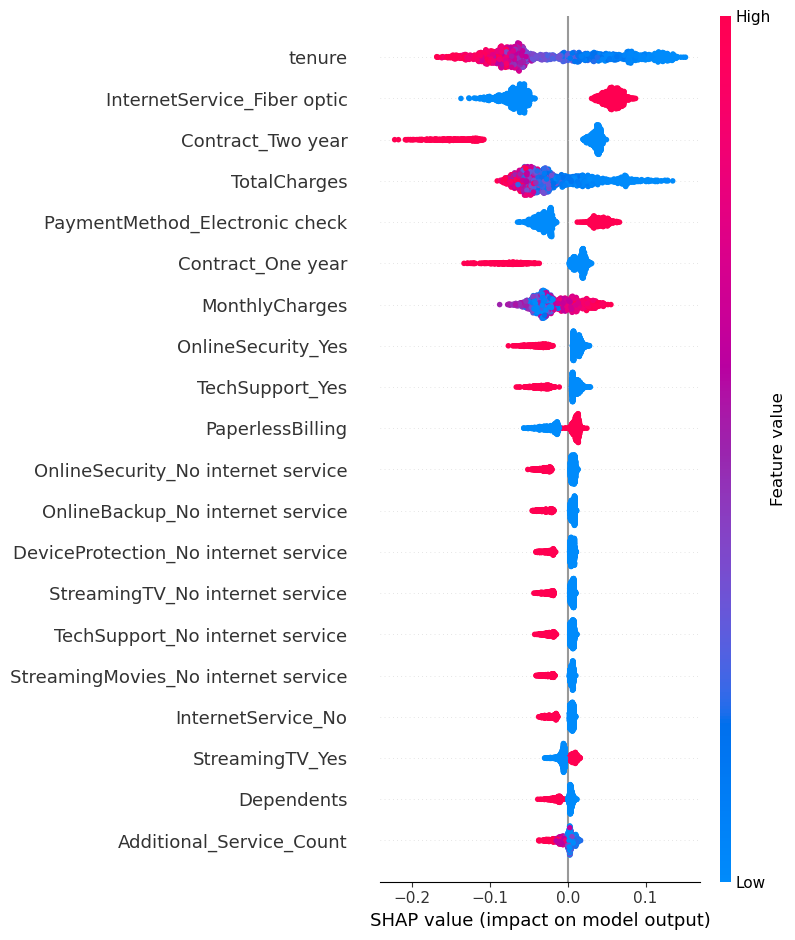

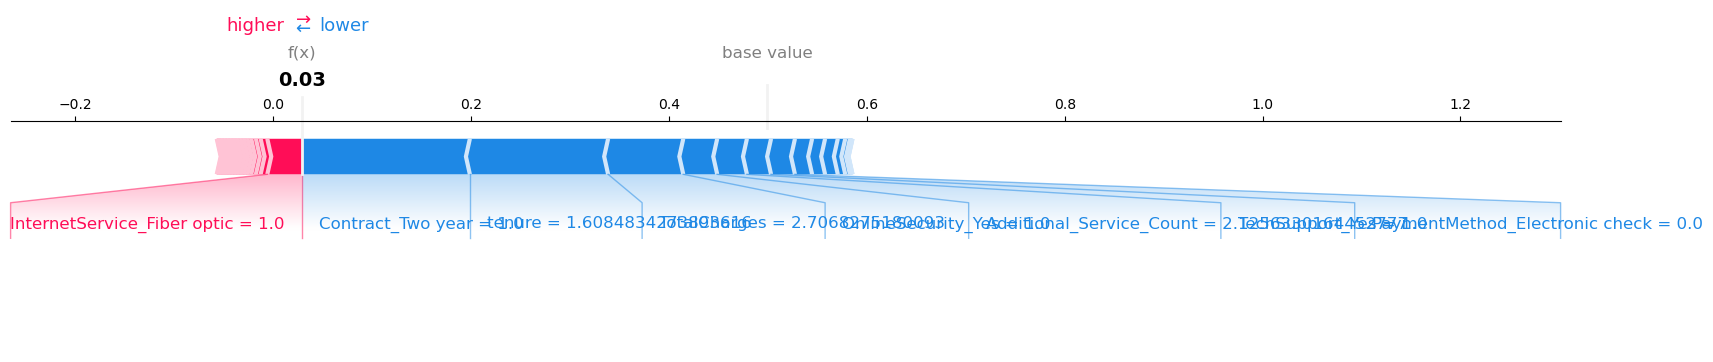

In [92]:
import shap

# STEP 1: Create explainer
explainer = shap.TreeExplainer(rf_model)

# STEP 2: Get SHAP values
shap_values = explainer.shap_values(x_test)

# STEP 3: Select class 1 (CHURN)
shap_vals = shap_values[:, :, 1]

# STEP 4: GLOBAL EXPLANATION (summary plot)
shap.summary_plot(shap_vals, x_test)

# STEP 5: SINGLE CUSTOMER EXPLANATION (force plot safe version)
shap.force_plot(
    explainer.expected_value[1],
    shap_vals[0],
    x_test.iloc[0],
    matplotlib=True
)